# Explainable Loan Approval Prediction Using Machine Learning: A Comparative Study of Classification Models and Explainable AI Techniques
**Dataset Source:** https://data.mendeley.com/datasets/k9wszywskf/2

In [1]:
!pip install -q xgboost shap lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

PROJECT_DIR = '/content/drive/MyDrive/LoanApprovalProject'

DATA_DIR = f'{PROJECT_DIR}/data'
OUTPUT_DIR = f'{PROJECT_DIR}/outputs'
MODEL_DIR = f'{PROJECT_DIR}/models'
CSV_PATH = f'{DATA_DIR}/loan_approval_dataset.csv'

for d in [DATA_DIR, OUTPUT_DIR, MODEL_DIR, f'{PROJECT_DIR}/notebooks']:
    os.makedirs(d, exist_ok=True)

print('Data will be read from:', CSV_PATH)

Data will be read from: /content/drive/MyDrive/LoanApprovalProject/data/loan_approval_dataset.csv


In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, roc_curve, classification_report)
from xgboost import XGBClassifier

import shap
from lime.lime_tabular import LimeTabularExplainer
from scipy.stats import spearmanr

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

## 2. Load the dataset

In [5]:
df = pd.read_csv(CSV_PATH)
print('Shape:', df.shape)
df.head()

Shape: (4269, 13)


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


## 3. Initial Data Quality Checks



In [6]:
print('Raw column names (note the leading spaces):')
print(list(df.columns))
print()
print('Missing values per column:')
print(df.isnull().sum())
print()
print('Duplicate rows:', df.duplicated().sum())
print()
print('Data types:')
print(df.dtypes)

Raw column names (note the leading spaces):
['loan_id', ' no_of_dependents', ' education', ' self_employed', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value', ' loan_status']

Missing values per column:
loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

Duplicate rows: 0

Data types:
loan_id                       int64
 no_of_dependents             int64
 education                   object
 self_employed               object
 income_annum                 int64
 loan_amount                  int64
 loan_term        

In [7]:
print('Raw categorical values before cleaning:')
print('education:', df[' education'].unique() if ' education' in df.columns else df['education'].unique())
print('self_employed:', df[' self_employed'].unique() if ' self_employed' in df.columns else df['self_employed'].unique())
print('loan_status:', df[' loan_status'].unique() if ' loan_status' in df.columns else df['loan_status'].unique())

Raw categorical values before cleaning:
education: [' Graduate' ' Not Graduate']
self_employed: [' No' ' Yes']
loan_status: [' Approved' ' Rejected']


In [18]:
df.drop_duplicates(inplace=True)

if df.isnull().sum().sum() > 0:
    df.fillna(df.median(numeric_only=True), inplace=True)

print("\nData cleaning completed.")
print("Remaining missing values:", df.isnull().sum().sum())
print("Remaining duplicate rows:", df.duplicated().sum())


Data cleaning completed.
Remaining missing values: 0
Remaining duplicate rows: 0


### 3.1 Data cleaning

In [8]:
df.columns = [c.strip() for c in df.columns]

for c in df.select_dtypes(include='object').columns:
    df[c] = df[c].astype(str).str.strip()

print('Column names after cleaning:')
print(list(df.columns))
print()
print('Categorical values after cleaning:')
print('education:', df['education'].unique())
print('self_employed:', df['self_employed'].unique())
print('loan_status:', df['loan_status'].unique())
print()
print('Missing values after cleaning:', df.isnull().sum().sum())
print('Duplicate rows after cleaning:', df.duplicated().sum())

Column names after cleaning:
['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']

Categorical values after cleaning:
education: ['Graduate' 'Not Graduate']
self_employed: ['No' 'Yes']
loan_status: ['Approved' 'Rejected']

Missing values after cleaning: 0
Duplicate rows after cleaning: 0


## 4. Exploratory Data Analysis

### 4.1 Univariate analysis: target class distribution



loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

Class balance (%):
loan_status
Approved    62.22
Rejected    37.78
Name: count, dtype: float64


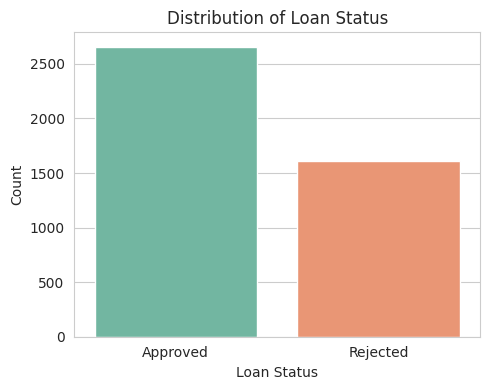

In [9]:
status_counts = df['loan_status'].value_counts()
print(status_counts)
print()
print('Class balance (%):')
print((status_counts / status_counts.sum() * 100).round(2))

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='loan_status', hue='loan_status', palette='Set2', legend=False)
plt.title('Distribution of Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 4.2 Univariate analysis: numeric feature distributions

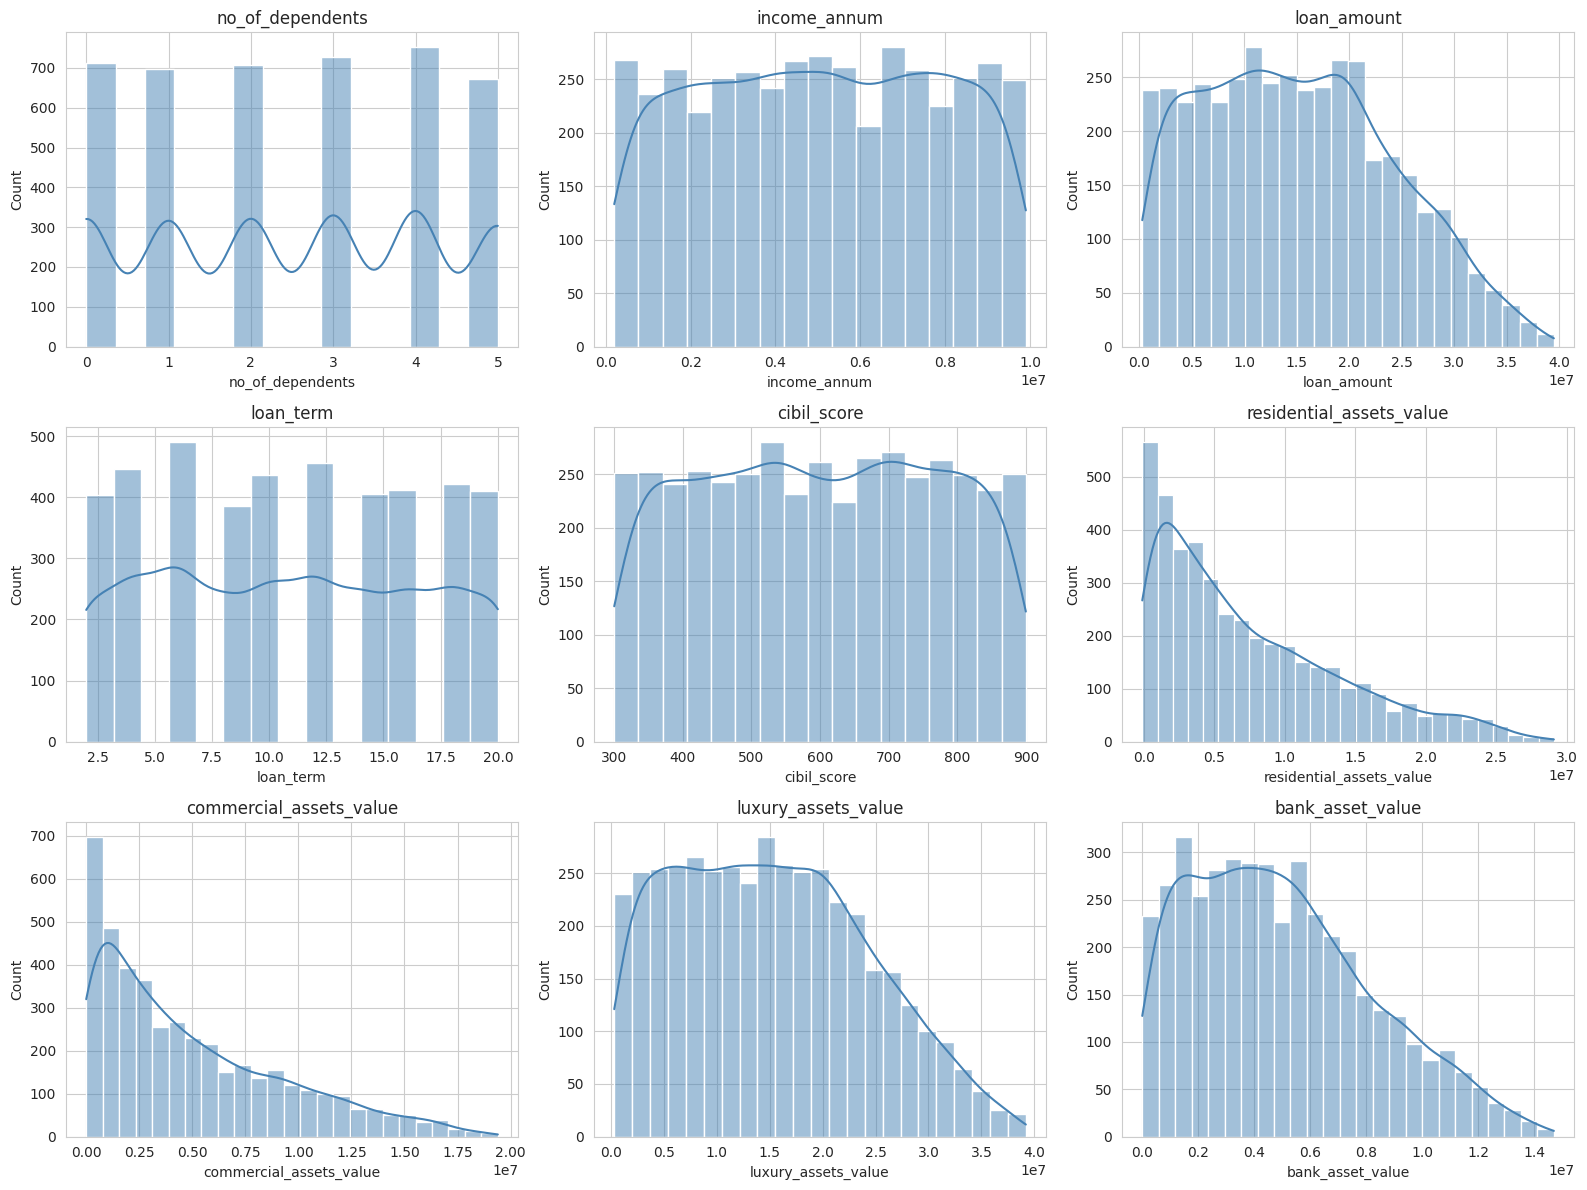

In [10]:
numeric_cols = ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
                'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value',
                'bank_asset_value']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

### 4.3 Univariate analysis: categorical features

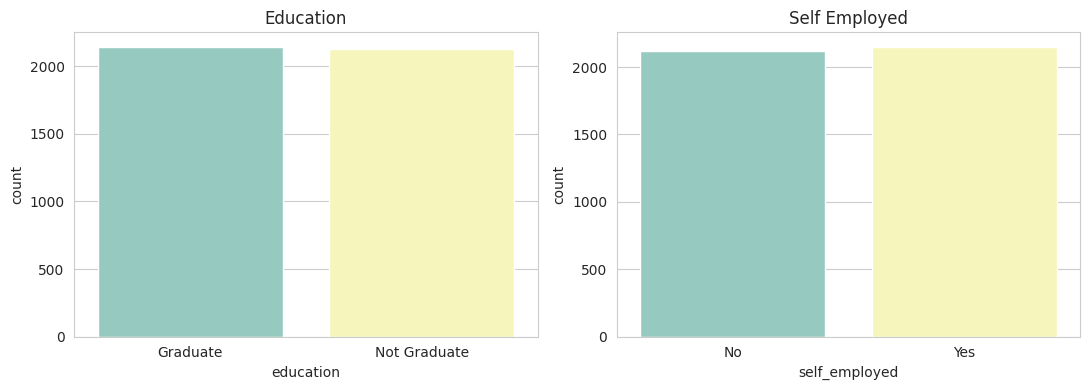

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=df, x='education', hue='education', palette='Set3', legend=False, ax=axes[0])
axes[0].set_title('Education')
sns.countplot(data=df, x='self_employed', hue='self_employed', palette='Set3', legend=False, ax=axes[1])
axes[1].set_title('Self Employed')
plt.tight_layout()
plt.show()

### 4.4 Multivariate analysis: correlation heatmap



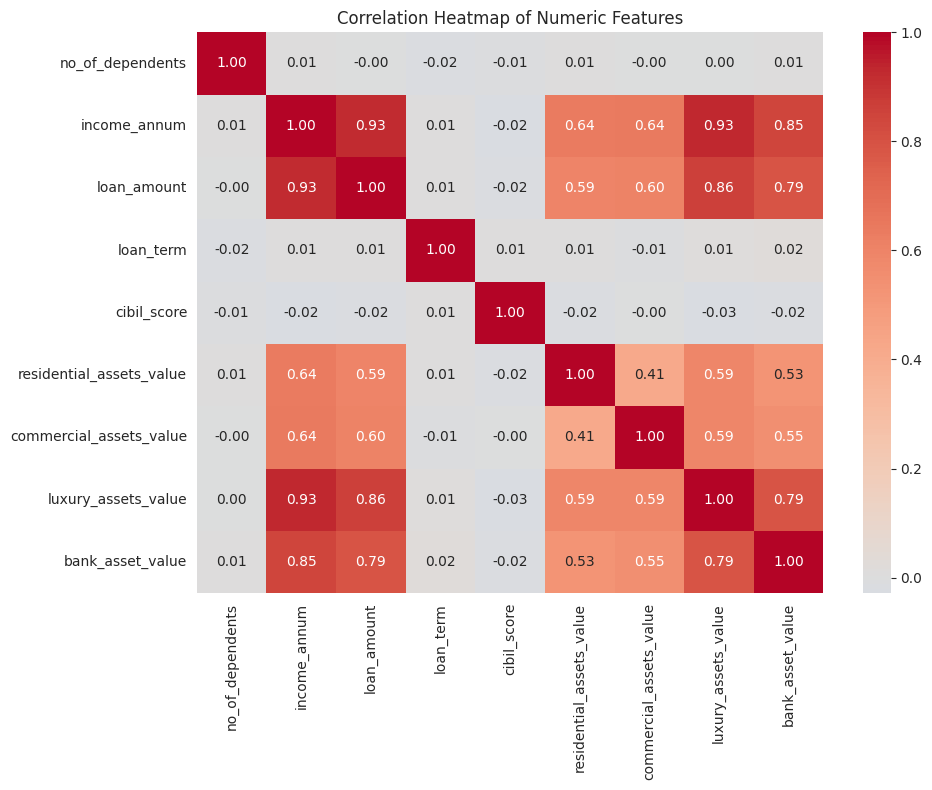

In [12]:
plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

### 4.5 Multivariate analysis: key features against loan status

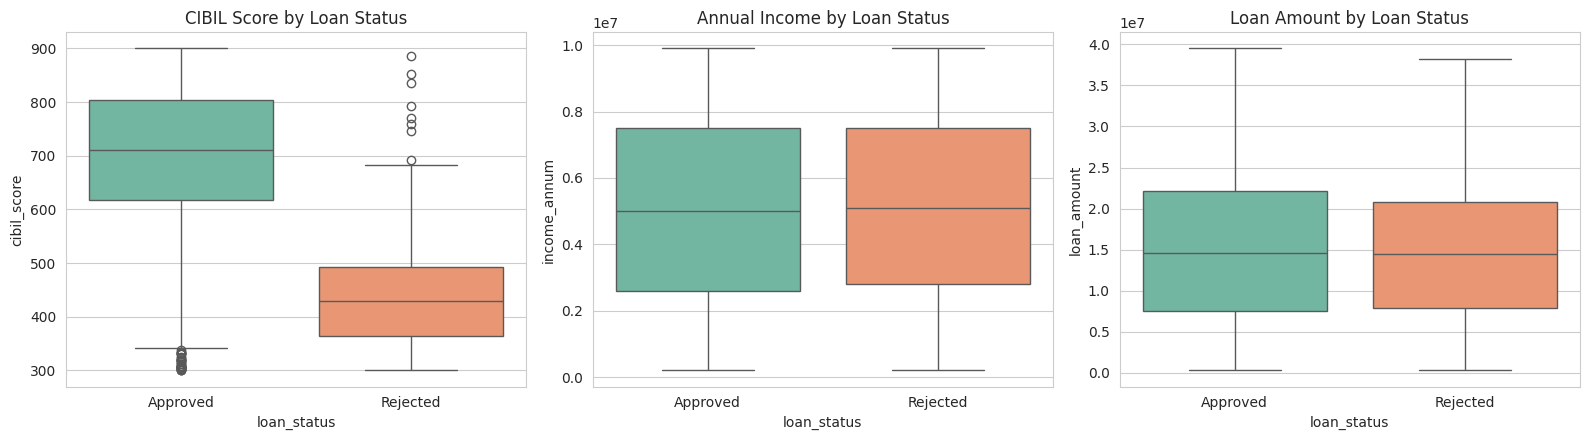

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.boxplot(data=df, x='loan_status', y='cibil_score', hue='loan_status', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('CIBIL Score by Loan Status')
sns.boxplot(data=df, x='loan_status', y='income_annum', hue='loan_status', palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Annual Income by Loan Status')
sns.boxplot(data=df, x='loan_status', y='loan_amount', hue='loan_status', palette='Set2', legend=False, ax=axes[2])
axes[2].set_title('Loan Amount by Loan Status')
plt.tight_layout()
plt.show()

In [14]:
print(df.groupby('loan_status')['cibil_score'].describe())

              count        mean         std    min    25%    50%    75%    max
loan_status                                                                   
Approved     2656.0  703.461973  125.249016  300.0  618.0  711.0  803.0  900.0
Rejected     1613.0  429.468072   78.401752  300.0  364.0  429.0  493.0  885.0


## 5. Feature Engineering



In [15]:
df_model = df.drop(columns=['loan_id']).copy()

df_model['education'] = df_model['education'].map({'Graduate': 1, 'Not Graduate': 0})
df_model['self_employed'] = df_model['self_employed'].map({'Yes': 1, 'No': 0})
df_model['loan_status'] = df_model['loan_status'].map({'Approved': 1, 'Rejected': 0})

df_model['total_assets_value'] = (df_model['residential_assets_value'] + df_model['commercial_assets_value']
                                   + df_model['luxury_assets_value'] + df_model['bank_asset_value'])
df_model['loan_to_income_ratio'] = df_model['loan_amount'] / df_model['income_annum']
df_model['asset_to_loan_ratio'] = df_model['total_assets_value'] / df_model['loan_amount']

df_model.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,total_assets_value,loan_to_income_ratio,asset_to_loan_ratio
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1,50700000,3.114583,1.695652
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,17000000,2.975610,1.393443
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,57700000,3.263736,1.942761
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,52700000,3.743902,1.716612
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,55000000,2.469388,2.272727


## 6. Train/Test Split and Scaling



In [16]:
X = df_model.drop(columns=['loan_status'])
y = df_model['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)
print('Train class balance:')
print(y_train.value_counts(normalize=True).round(3))

Train shape: (3415, 14)  Test shape: (854, 14)
Train class balance:
loan_status
1    0.622
0    0.378
Name: proportion, dtype: float64


## 7. Model Development



In [17]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=10, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                              random_state=RANDOM_STATE, eval_metric='logloss')
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = []
fitted_models = {}
test_predictions = {}
test_probabilities = {}

for name, model in models.items():
    use_scaled = (name == 'Logistic Regression')
    Xtr = X_train_scaled if use_scaled else X_train
    Xte = X_test_scaled if use_scaled else X_test

    cv_scores = cross_val_score(model, Xtr, y_train, cv=skf, scoring='accuracy')
    model.fit(Xtr, y_train)

    preds = model.predict(Xte)
    proba = model.predict_proba(Xte)[:, 1]

    fitted_models[name] = model
    test_predictions[name] = preds
    test_probabilities[name] = proba

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds),
        'ROC-AUC': roc_auc_score(y_test, proba),
        '5-Fold CV Mean Accuracy': cv_scores.mean(),
        '5-Fold CV Std': cv_scores.std()
    })

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,5-Fold CV Mean Accuracy,5-Fold CV Std
0,Decision Tree,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
1,Random Forest,0.998829,0.998120,1.000000,0.999059,1.000000,0.997950,0.001171
2,XGBoost,0.997658,0.998117,0.998117,0.998117,0.999988,0.997950,0.002716
3,Logistic Regression,0.913349,0.919266,0.943503,0.931227,0.972894,0.910102,0.018160


### 7.1 Classification reports

In [20]:
for name in models:
    print(f'--- {name} ---')
    use_scaled = (name == 'Logistic Regression')
    yte = y_test
    print(classification_report(yte, test_predictions[name], target_names=['Rejected', 'Approved']))

--- Logistic Regression ---
              precision    recall  f1-score   support

    Rejected       0.90      0.86      0.88       323
    Approved       0.92      0.94      0.93       531

    accuracy                           0.91       854
   macro avg       0.91      0.90      0.91       854
weighted avg       0.91      0.91      0.91       854

--- Decision Tree ---
              precision    recall  f1-score   support

    Rejected       1.00      1.00      1.00       323
    Approved       1.00      1.00      1.00       531

    accuracy                           1.00       854
   macro avg       1.00      1.00      1.00       854
weighted avg       1.00      1.00      1.00       854

--- Random Forest ---
              precision    recall  f1-score   support

    Rejected       1.00      1.00      1.00       323
    Approved       1.00      1.00      1.00       531

    accuracy                           1.00       854
   macro avg       1.00      1.00      1.00       854
we

### 7.2 Confusion matrices

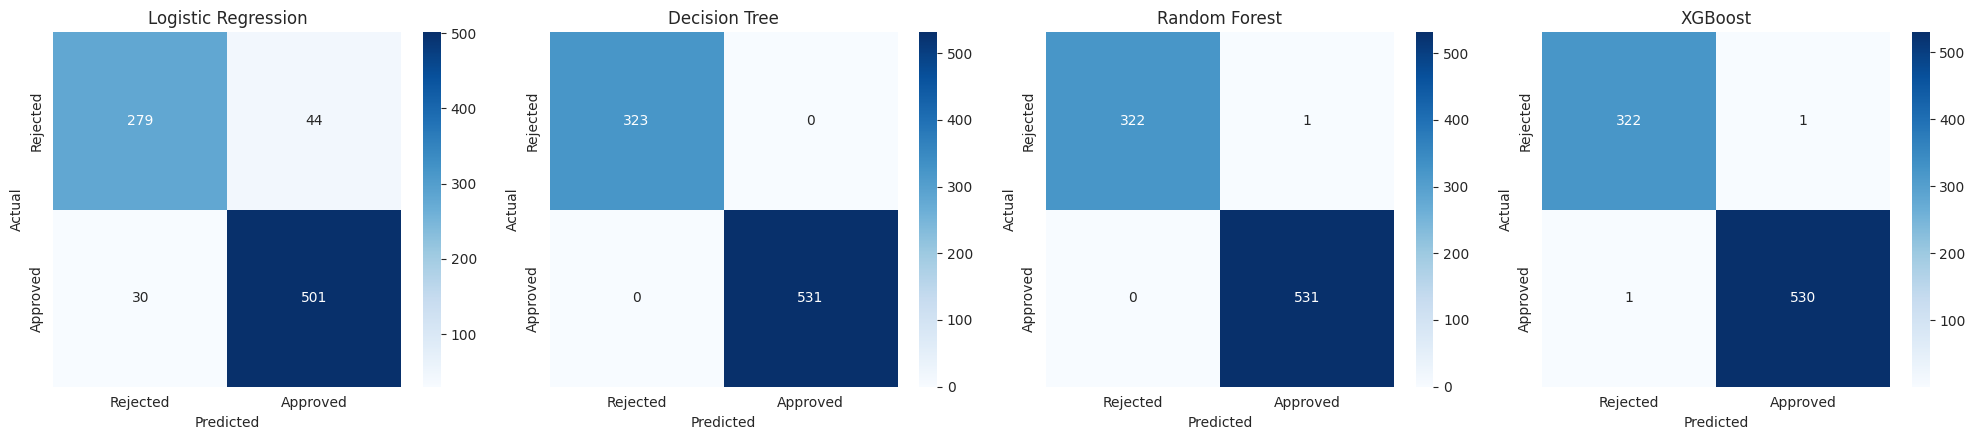

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, name in zip(axes, models):
    cm = confusion_matrix(y_test, test_predictions[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Rejected', 'Approved'], yticklabels=['Rejected', 'Approved'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

### 7.3 ROC curves

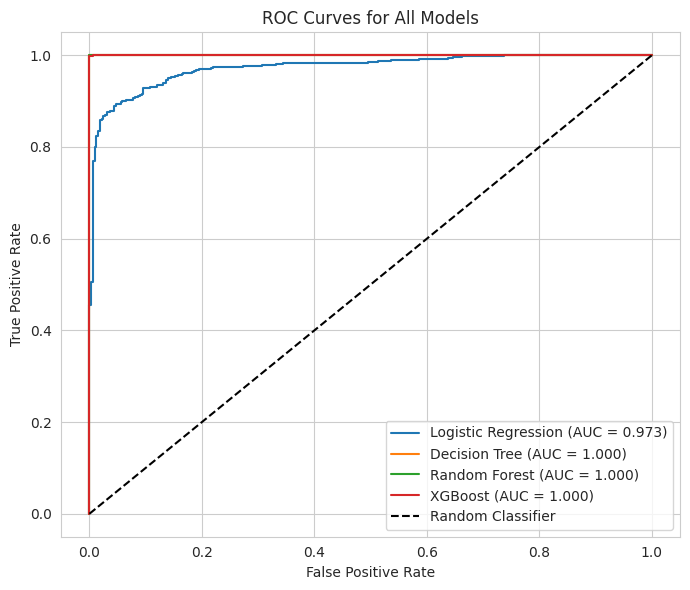

In [22]:
plt.figure(figsize=(7, 6))
for name in models:
    fpr, tpr, _ = roc_curve(y_test, test_probabilities[name])
    auc_val = roc_auc_score(y_test, test_probabilities[name])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Models')
plt.legend()
plt.tight_layout()
plt.show()

### 7.4 Model comparison chart

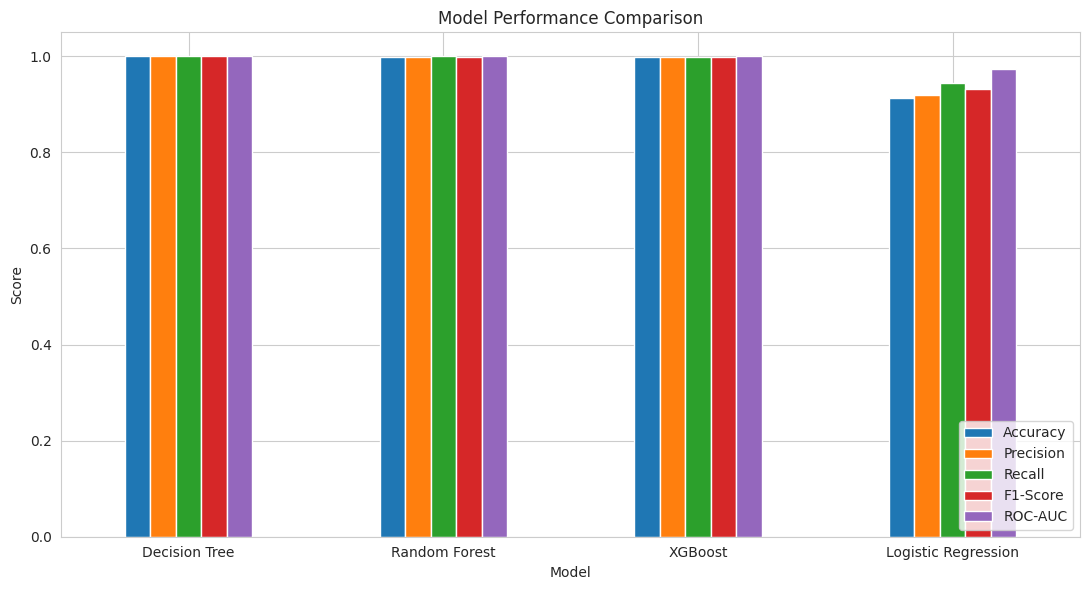

Best model by F1-Score: Decision Tree


In [23]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
plot_df = results_df.set_index('Model')[metrics_to_plot]

plot_df.plot(kind='bar', figsize=(11, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]['Model']
print('Best model by F1-Score:', best_model_name)

## 8. Native Feature Importance



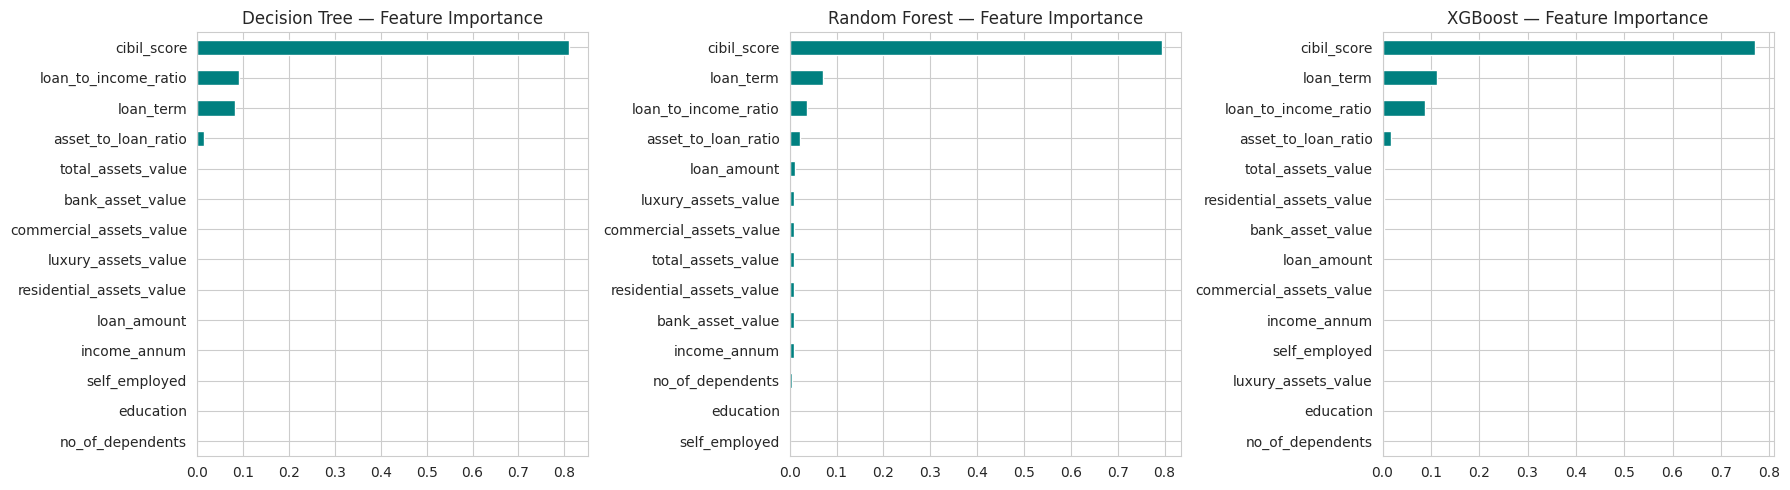

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
tree_models = ['Decision Tree', 'Random Forest', 'XGBoost']
for ax, name in zip(axes, tree_models):
    importances = pd.Series(fitted_models[name].feature_importances_, index=X_train.columns)
    importances = importances.sort_values(ascending=True)
    importances.plot(kind='barh', ax=ax, color='teal')
    ax.set_title(f'{name} — Feature Importance')
plt.tight_layout()
plt.show()

## 9. Explainability: SHAP and LIME



### 9.1 SHAP (SHapley Additive exPlanations)

In [25]:
explain_model_name = 'XGBoost'
explain_model = fitted_models[explain_model_name]

explainer_shap = shap.TreeExplainer(explain_model)
shap_values = explainer_shap.shap_values(X_test)
shap_values = np.array(shap_values)
if shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]

print('SHAP values shape:', shap_values.shape)

SHAP values shape: (854, 14)


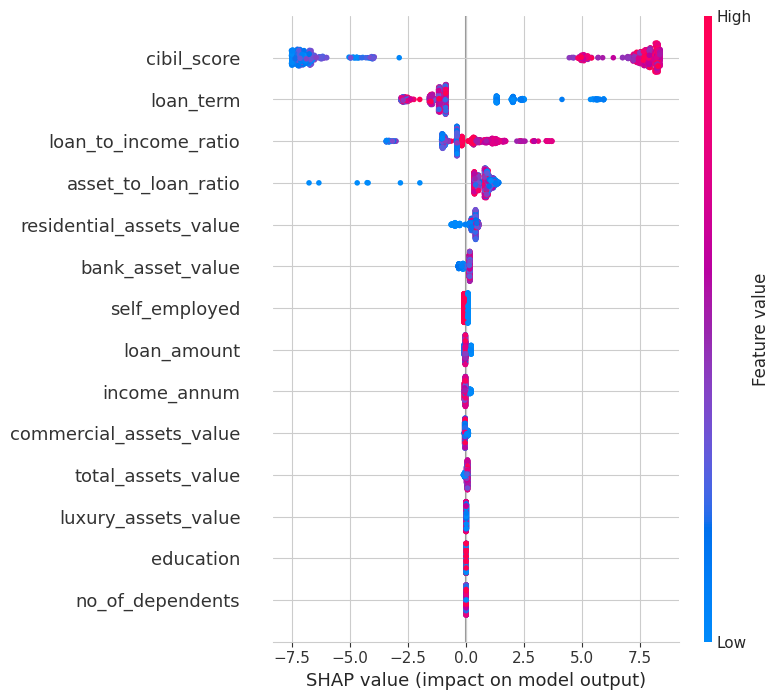

In [26]:
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.show()

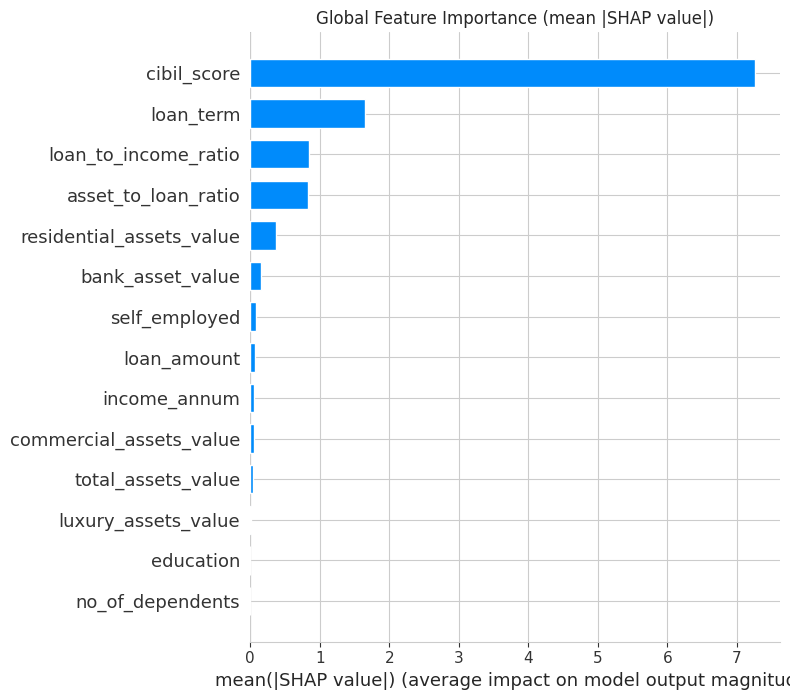

In [27]:
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('Global Feature Importance (mean |SHAP value|)')
plt.tight_layout()
plt.show()

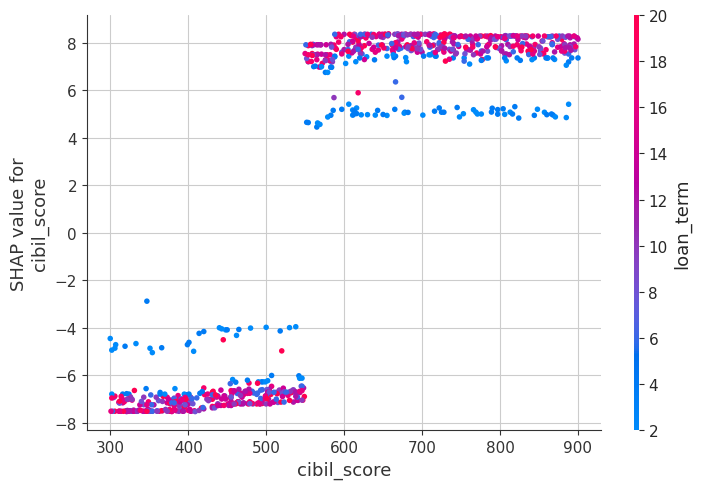

In [28]:
shap.dependence_plot('cibil_score', shap_values, X_test, show=False)
plt.tight_layout()
plt.show()

In [29]:
shap_importance = pd.Series(np.abs(shap_values).mean(axis=0), index=X_test.columns)
shap_importance = shap_importance.sort_values(ascending=False)
print('SHAP global feature ranking:')
print(shap_importance)

SHAP global feature ranking:
cibil_score                 7.256436
loan_term                   1.647423
loan_to_income_ratio        0.848167
asset_to_loan_ratio         0.832878
residential_assets_value    0.373779
bank_asset_value            0.163928
self_employed               0.079929
loan_amount                 0.068962
income_annum                0.053678
commercial_assets_value     0.051843
total_assets_value          0.046104
luxury_assets_value         0.005914
no_of_dependents            0.000000
education                   0.000000
dtype: float32


### 9.2 LIME (Local Interpretable Model-agnostic Explanations)

In [30]:
explainer_lime = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=list(X_train.columns),
    class_names=['Rejected', 'Approved'],
    mode='classification',
    random_state=RANDOM_STATE
)

# Explain one approved and one rejected test instance
approved_idx = y_test[y_test == 1].index[0]
rejected_idx = y_test[y_test == 0].index[0]

for label, idx in [('Approved example', approved_idx), ('Rejected example', rejected_idx)]:
    row_pos = X_test.index.get_loc(idx)
    exp = explainer_lime.explain_instance(
        np.array(X_test.iloc[row_pos]), explain_model.predict_proba, num_features=10
    )
    print(f'--- LIME explanation: {label} ---')
    for feat, weight in exp.as_list():
        print(f'  {feat}: {weight:.4f}')
    print()

--- LIME explanation: Approved example ---
  598.00 < cibil_score <= 749.00: 0.4835
  loan_term <= 6.00: 0.1943
  3.00 < loan_to_income_ratio <= 3.50: 0.1020
  education <= 0.00: 0.0127
  commercial_assets_value <= 1300000.00: 0.0117
  self_employed <= 0.00: 0.0113
  16300000.00 < total_assets_value <= 31500000.00: -0.0109
  asset_to_loan_ratio <= 1.77: -0.0089
  7500000.00 < luxury_assets_value <= 14600000.00: -0.0080
  no_of_dependents <= 1.00: -0.0075

--- LIME explanation: Rejected example ---
  598.00 < cibil_score <= 749.00: 0.4884
  loan_term <= 6.00: 0.2257
  loan_to_income_ratio > 3.50: 0.1064
  1300000.00 < commercial_assets_value <= 3700000.00: 0.0289
  loan_amount > 21300000.00: -0.0250
  4500000.00 < bank_asset_value <= 7000000.00: -0.0199
  14600000.00 < luxury_assets_value <= 21600000.00: 0.0172
  income_annum > 7400000.00: -0.0140
  residential_assets_value <= 2200000.00: 0.0122
  16300000.00 < total_assets_value <= 31500000.00: -0.0099



In [31]:
N_SAMPLES = 60
sample_positions = np.random.RandomState(RANDOM_STATE).choice(len(X_test), size=N_SAMPLES, replace=False)

lime_importance = pd.Series(0.0, index=X_test.columns)
for pos in sample_positions:
    exp = explainer_lime.explain_instance(
        np.array(X_test.iloc[pos]), explain_model.predict_proba, num_features=len(X_test.columns)
    )
    for feat_desc, weight in exp.as_list():
        for col in X_test.columns:
            if col in feat_desc:
                lime_importance[col] += abs(weight)
                break

lime_importance = (lime_importance / N_SAMPLES).sort_values(ascending=False)
print('LIME global feature ranking (aggregated over', N_SAMPLES, 'test instances):')
print(lime_importance)

LIME global feature ranking (aggregated over 60 test instances):
cibil_score                 0.497739
loan_term                   0.122822
loan_to_income_ratio        0.090866
total_assets_value          0.011521
bank_asset_value            0.011277
commercial_assets_value     0.011268
residential_assets_value    0.010910
no_of_dependents            0.010795
loan_amount                 0.010717
asset_to_loan_ratio         0.010408
self_employed               0.009659
education                   0.009536
income_annum                0.009344
luxury_assets_value         0.009205
dtype: float64


### 9.3 Comparing SHAP and LIME (RQ3 / RQ4)

In [32]:
comparison_df = pd.DataFrame({
    'SHAP Importance': shap_importance,
    'LIME Importance': lime_importance
}).sort_values('SHAP Importance', ascending=False)

comparison_df['SHAP Rank'] = comparison_df['SHAP Importance'].rank(ascending=False)
comparison_df['LIME Rank'] = comparison_df['LIME Importance'].rank(ascending=False)
comparison_df

,SHAP Importance,LIME Importance,SHAP Rank,LIME Rank
cibil_score,7.256436,0.497739,1.0,1.0
loan_term,1.647423,0.122822,2.0,2.0
loan_to_income_ratio,0.848167,0.090866,3.0,3.0
asset_to_loan_ratio,0.832878,0.010408,4.0,10.0
residential_assets_value,0.373779,0.010910,5.0,7.0
bank_asset_value,0.163928,0.011277,6.0,5.0
self_employed,0.079929,0.009659,7.0,11.0
loan_amount,0.068962,0.010717,8.0,9.0
income_annum,0.053678,0.009344,9.0,13.0
commercial_assets_value,0.051843,0.011268,10.0,6.0


Spearman rank correlation between SHAP and LIME feature rankings: 0.614 (p = 0.0195)


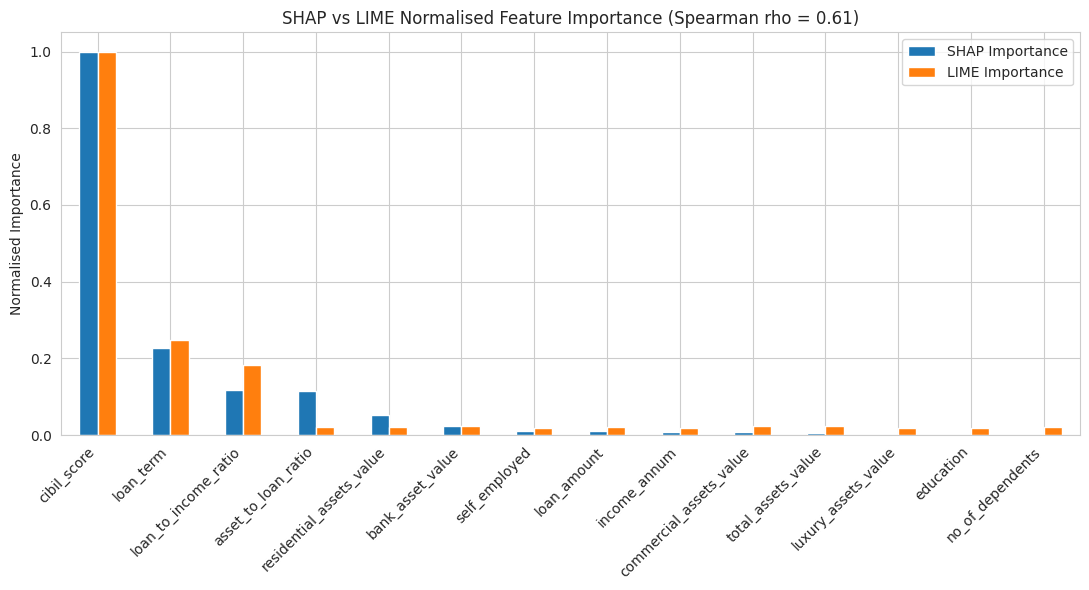

In [33]:
rho, pval = spearmanr(comparison_df['SHAP Rank'], comparison_df['LIME Rank'])
print(f'Spearman rank correlation between SHAP and LIME feature rankings: {rho:.3f} (p = {pval:.4f})')

fig, ax = plt.subplots(figsize=(11, 6))
comparison_norm = comparison_df[['SHAP Importance', 'LIME Importance']].copy()
comparison_norm = comparison_norm / comparison_norm.max()
comparison_norm.plot(kind='bar', ax=ax)
plt.title(f'SHAP vs LIME Normalised Feature Importance (Spearman rho = {rho:.2f})')
plt.ylabel('Normalised Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 10. Fairness and Bias Considerations



In [34]:
for col in ['education', 'self_employed']:
    print(f'Approval rate by {col}:')
    print(df.groupby(col)['loan_status'].apply(lambda s: (s == 'Approved').mean()).round(3))
    print()

Approval rate by education:
education
Graduate        0.625
Not Graduate    0.620
Name: loan_status, dtype: float64

Approval rate by self_employed:
self_employed
No     0.622
Yes    0.622
Name: loan_status, dtype: float64



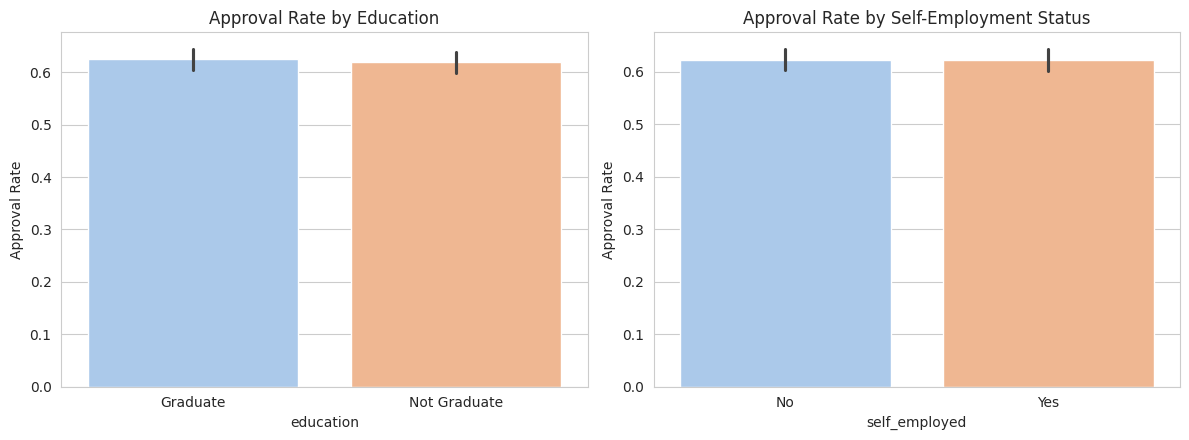

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(data=df, x='education', y=(df['loan_status'] == 'Approved').astype(int),
            hue='education', palette='pastel', legend=False, ax=axes[0])
axes[0].set_title('Approval Rate by Education')
axes[0].set_ylabel('Approval Rate')

sns.barplot(data=df, x='self_employed', y=(df['loan_status'] == 'Approved').astype(int),
            hue='self_employed', palette='pastel', legend=False, ax=axes[1])
axes[1].set_title('Approval Rate by Self-Employment Status')
axes[1].set_ylabel('Approval Rate')
plt.tight_layout()
plt.show()

## 11. Save Artifacts



In [36]:
import joblib

for name, model in fitted_models.items():
    fname = name.lower().replace(' ', '_')
    joblib.dump(model, f'{MODEL_DIR}/{fname}.joblib')

joblib.dump(scaler, f'{MODEL_DIR}/scaler.joblib')
results_df.to_csv(f'{OUTPUT_DIR}/model_comparison_results.csv', index=False)
comparison_df.to_csv(f'{OUTPUT_DIR}/shap_lime_comparison.csv')

print('Saved trained models and scaler to:', MODEL_DIR)
print('Saved results tables to:', OUTPUT_DIR)

Saved trained models and scaler to: /content/drive/MyDrive/LoanApprovalProject/models
Saved results tables to: /content/drive/MyDrive/LoanApprovalProject/outputs
